In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import corner

from bilby.gw.conversion import lambda_1_lambda_2_to_lambda_tilde, lambda_1_lambda_2_to_delta_lambda_tilde, lambda_tilde_delta_lambda_tilde_to_lambda_1_lambda_2

In [3]:
narrow_df = pd.read_csv("../../events/gw/gw_params_narrow.dat", sep=" ")
detection_df = pd.read_csv("../../events/detection/detection_output/narrow_ETL.dat", sep=" ")
events = pd.read_csv("events.dat", sep=" ")
events["mass_ratio"] = events["mass_2"] / events["mass_1"]

In [4]:
n_coll = np.sum(events["prompt_collapse"] ==1 )
n_tot = events.shape[0]
pop_coll_share = np.sum(narrow_df["prompt_collapse"]==1)/narrow_df.shape[0]

print(f"Prompt collapse: {n_coll}/{n_tot}, {n_coll/n_tot:.3f}, ", pop_coll_share)

Prompt collapse: 3/85, 0.035,  0.09623246050160203


In [5]:
log10_mej_wind = events["log10_mej_wind"]
zeta = 10**(events["log10_mej_wind"] - events["log10_mdisk"])

print("wind quantile: ", np.quantile(log10_mej_wind, 0.05))
print("zeta quantile: ", np.quantile(zeta, 0.05))

wind quantile:  -1.7047591251052596
zeta quantile:  0.13735090638516925


In [6]:
print("SNR min max: ", np.min(events["snr"]), np.max(events["snr"]))

SNR min max:  13.101 238.636


In [7]:
events["log10_mej_wind"].min()

np.float64(-2.658515778987854)

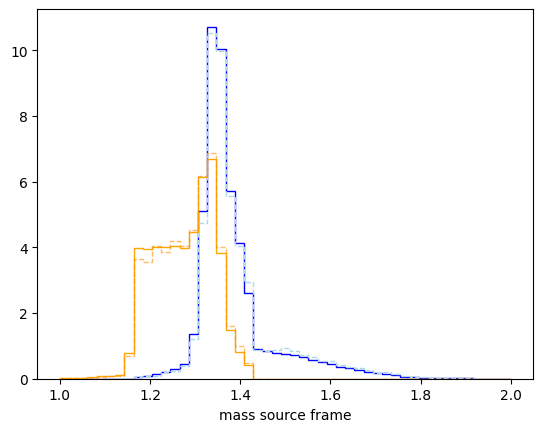

In [8]:
bins = np.linspace(1, 2, 50)

plt.hist(narrow_df["mass_1_source"], bins=bins, density=True, histtype="step", color="blue")
plt.hist(narrow_df.loc[detection_df["gw_detected"].astype(bool), "mass_1_source"], bins=bins, density=True, histtype="step", color="lightblue", linestyle="dashed")

plt.hist(narrow_df["mass_2_source"], bins=bins, density=True, color="orange", histtype="step")
plt.hist(narrow_df.loc[detection_df["gw_detected"].astype(bool), "mass_2_source"], bins=bins, density=True, histtype="step", alpha=0.6, color="darkorange", linestyle="dashed")


plt.xlabel("mass source frame")
plt.show()

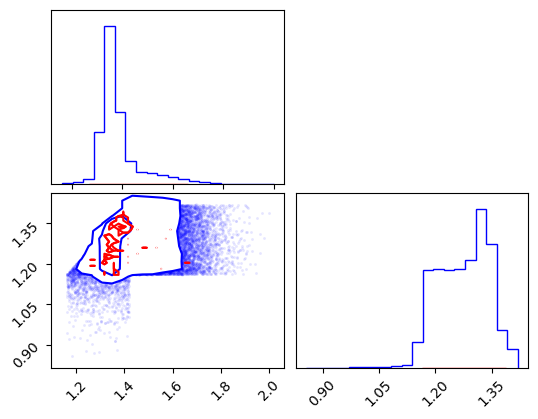

In [9]:
fig, ax = plt.subplots(2,2)

corner.corner(np.array([narrow_df["mass_1_source"], narrow_df["mass_2_source"]]).T,
                       color="blue", fig=fig, plot_density=False, levels=[0.68, 0.95])

corner.corner(np.array([events["mass_1_source"], events["mass_2_source"]]).T,
                       color="red", fig=fig, plot_density=False, levels=[0.68, 0.95])

fig.show()

(array([ 9., 12., 12.,  6.,  8., 10.,  8.,  9.,  7.,  4.]),
 array([0.20001408, 0.21963481, 0.23925555, 0.25887628, 0.27849701,
        0.29811774, 0.31773847, 0.3373592 , 0.35697993, 0.37660066,
        0.3962214 ]),
 [<matplotlib.patches.Polygon at 0x7f8455a00050>])

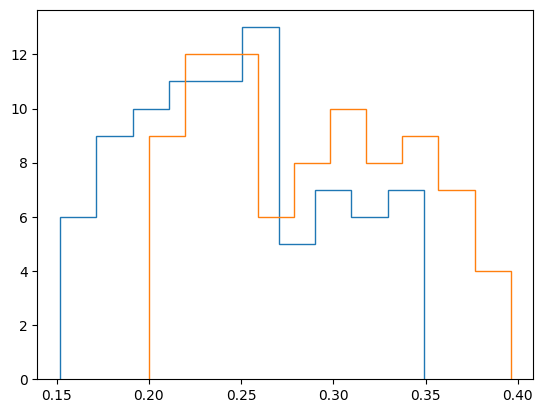

In [10]:
plt.hist(events.loc[:, "Ye_dyn"], histtype="step")
plt.hist(events.loc[:, "Ye_wind"], histtype="step")



(array([ 3., 11., 10., 16., 14., 24.,  4.,  1.,  1.,  1.]),
 array([0.17679755, 0.18226986, 0.18774218, 0.19321449, 0.19868681,
        0.20415912, 0.20963143, 0.21510375, 0.22057606, 0.22604838,
        0.23152069]),
 [<matplotlib.patches.Polygon at 0x7f845579a290>])

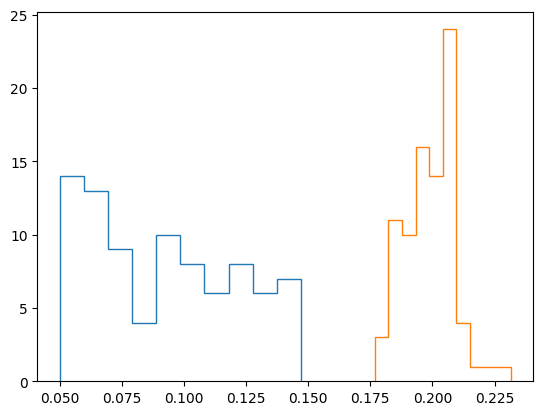

In [11]:
plt.hist(events.loc[:, "v_ej_wind"], histtype="step")
plt.hist(events.loc[:, "v_ej_dyn"], histtype="step")


(array([4.69294362e-03, 4.05801595e-02, 1.55143195e-01, 3.92550931e-01,
        7.15259819e-01, 1.06419398e+00, 2.58056688e+00, 4.91047536e+00,
        6.61870684e+00, 8.50361384e+00]),
 array([0.5997643 , 0.63978706, 0.67980982, 0.71983258, 0.75985534,
        0.79987809, 0.83990085, 0.87992361, 0.91994637, 0.95996913,
        0.99999189]),
 [<matplotlib.patches.Polygon at 0x7f84557f5e90>])

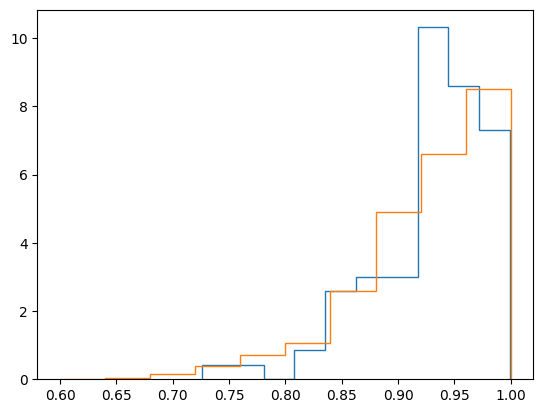

In [12]:
plt.hist(events["mass_ratio"], density=True, histtype="step")
plt.hist(narrow_df["mass_2"] / narrow_df["mass_1"], density=True, histtype="step")

(array([9.83281365e-04, 1.37659391e-02, 1.01769621e-01, 1.88478650e+00,
        3.28924005e+00, 1.59193253e+00, 3.94459708e-01, 1.19632566e-01,
        1.84365256e-02, 1.39298193e-03]),
 array([2.03970241, 2.17453872, 2.30937504, 2.44421135, 2.57904767,
        2.71388398, 2.84872029, 2.98355661, 3.11839292, 3.25322924,
        3.38806555]),
 [<matplotlib.patches.Polygon at 0x7f8455b1f010>])

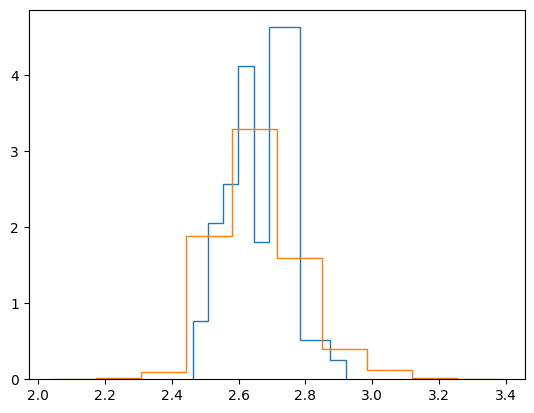

In [13]:
plt.hist(events["mass_2_source"] + events["mass_1_source"], density=True, histtype="step")
plt.hist(narrow_df["mass_2_source"] + narrow_df["mass_1_source"], density=True, histtype="step")

(array([35., 19.,  8.,  8.,  6.,  7.,  1.,  0.,  0.,  1.]),
 array([ 277.72178136,  652.36690431, 1027.01202727, 1401.65715022,
        1776.30227317, 2150.94739612, 2525.59251907, 2900.23764203,
        3274.88276498, 3649.52788793, 4024.17301088]),
 <BarContainer object of 10 artists>)

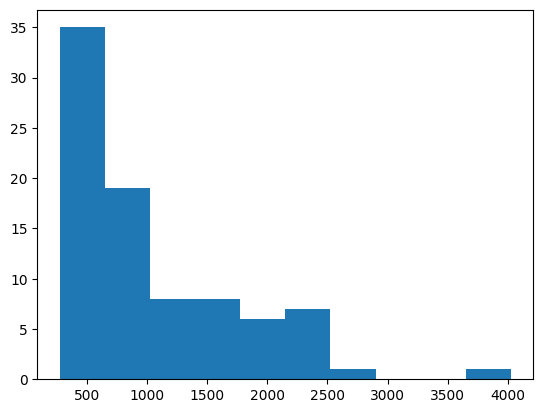

In [14]:
plt.hist(events["luminosity_distance"])

In [21]:
narrow_df["mass_1_source"].min()

np.float64(1.160187479811348)

In [20]:
np.sort(events["mass_1_source"])

array([1.26788802, 1.26798571, 1.30963811, 1.31390997, 1.31497813,
       1.31641105, 1.31902493, 1.31925627, 1.32657948, 1.32864559,
       1.33074508, 1.33183186, 1.33309246, 1.33319408, 1.3341304 ,
       1.33520221, 1.33687397, 1.33712714, 1.3373071 , 1.34247434,
       1.34348849, 1.34378731, 1.34478798, 1.34494561, 1.3467433 ,
       1.34770834, 1.34913033, 1.34999875, 1.35263322, 1.3531372 ,
       1.35416849, 1.35544021, 1.35625849, 1.35678242, 1.361301  ,
       1.36384449, 1.36512611, 1.3658301 , 1.3662125 , 1.36628629,
       1.36797498, 1.3687834 , 1.36941511, 1.37108371, 1.37476914,
       1.37729636, 1.37763066, 1.37986889, 1.38035752, 1.38045784,
       1.38405333, 1.38595692, 1.38666822, 1.38919623, 1.3925323 ,
       1.39559436, 1.39987164, 1.40001565, 1.40047935, 1.40050251,
       1.40313319, 1.40387166, 1.40610633, 1.40765665, 1.41141269,
       1.4117032 , 1.4129478 , 1.41352306, 1.41393198, 1.41512964,
       1.41619491, 1.41805918, 1.41840602, 1.4219525 , 1.42249